In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import os
from scipy import stats
from pathlib import Path

In [2]:
#tableau_resultat = pd.read_csv('../../output_data/resultats_tableau.csv', index_col=0)
#output_dir = '../../output_data/Figures'
#os.makedirs(output_dir, exist_ok=True)
#print(tableau_resultat.columns)

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "output_data"))
figures_dir = Path(os.environ.get("FIGURES_DIR", "output_data/Figures"))
os.makedirs(figures_dir, exist_ok=True)

tableau_resultat = pd.read_csv(output_dir / "resultats_tableau.csv", index_col=0)

In [3]:
# Mettre dans le bon format
df_sam = tableau_resultat[['sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100', 'sam_AVG_seg2gt', 'sam_AVG_gt2seg']].copy()
df_sam.columns = ['dice', 'precision', 'recall', 'HD100', 'AVG_seg2gt', 'AVG_gt2seg']
df_sam['modele'] = 'SAM'

df_medsam = tableau_resultat[['medsam_dice', 'medsam_precision', 'medsam_recall', 'medsam_HD100', 'medsam_AVG_seg2gt', 'medsam_AVG_gt2seg']].copy()
df_medsam.columns = ['dice', 'precision', 'recall', 'HD100', 'AVG_seg2gt', 'AVG_gt2seg']
df_medsam['modele'] = 'MedSAM'

df_long = pd.concat([df_sam, df_medsam])

print(df_long.columns)

Index(['dice', 'precision', 'recall', 'HD100', 'AVG_seg2gt', 'AVG_gt2seg',
       'modele'],
      dtype='str')


# Tests t pour chaque métrique

In [4]:
metriques = ['dice', 'precision', 'recall', 'HD100', 'AVG_seg2gt', 'AVG_gt2seg']

resultats_stats = {}
for metrique in metriques:
    sam_vals = df_long[df_long['modele'] == 'SAM'][metrique].values
    medsam_vals = df_long[df_long['modele'] == 'MedSAM'][metrique].values
    t_stat, p_val = stats.ttest_rel(sam_vals, medsam_vals)
    resultats_stats[metrique] = {'t': t_stat, 'p': p_val}

df_stats = pd.DataFrame(resultats_stats)

print(df_stats)

       dice  precision        recall     HD100    AVG_seg2gt  AVG_gt2seg
t -3.277805   2.477297 -8.806819e+00  4.201374  9.012708e+00    0.011383
p  0.002048   0.017151  2.888510e-11  0.000127  1.490128e-11    0.990970


# Figure Dice 

### Figure

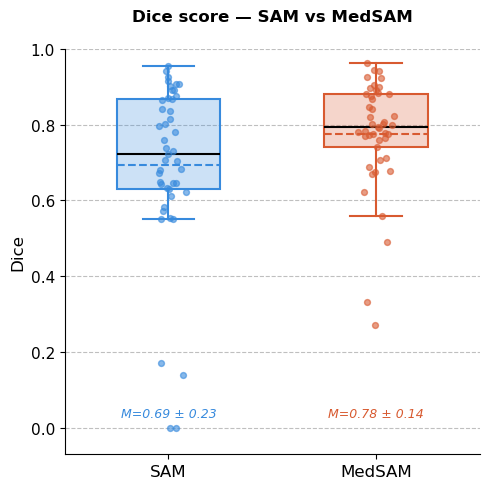

Figure sauvegardée : /home/cassa2/psy3019/projet_repro/output_data/figure_dice.png
Boxplot_sauvegardé


In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

modeles = ['SAM', 'MedSAM']
couleurs = {'SAM': '#378ADD', 'MedSAM': '#D85A30'}

# --- Boxplot avec transparence via boxprops ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele][['modele', 'dice']]
    bp = ax.boxplot(
        vals['dice'],
        positions=[i],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color=couleurs[modele], linewidth=1.5),
        capprops=dict(color=couleurs[modele], linewidth=1.5),
        boxprops=dict(facecolor=couleurs[modele] + '40',   # '40' ≈ 25% opacité
                    edgecolor=couleurs[modele], linewidth=1.5),
        flierprops=dict(marker=''),
        showfliers=False
    )

    # Ligne de moyenne tiretée
    mu = vals['dice'].mean()
    ax.hlines(mu, i - 0.25, i + 0.25,
            colors=couleurs[modele], linewidths=1.5,
            linestyles='--', zorder=5)

# --- Points décalés à droite ---
''
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['dice']
    x = np.random.normal(i, 0.04, size=len(vals))
    ax.scatter(x, vals, color=couleurs[modele], alpha=0.6, s=18, zorder=3)

# --- Annotations μ ± σ ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['dice']
    mu, sigma = vals.mean(), vals.std()
    ax.annotate(
        f'M={mu:.2f} ± {sigma:.2f}',
        xy=(i, 0.02), ha='center', va='bottom',
        fontsize=9, color=couleurs[modele], fontstyle='italic'
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['SAM', 'MedSAM'], fontsize=12)
ax.set_ylabel('Dice', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(-0.07, 1)
ax.yaxis.set_tick_params(labelsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

'''
# --- Barre de significativité ---
y_bar = 0.92  # hauteur de la barre, ajuste selon tes données
ax.plot([0, 0, 1, 1], [y_bar - 0.02, y_bar, y_bar, y_bar - 0.02],
        color='black', linewidth=1.2)

# Étoiles selon p-value
if p_val < 0.001:
    sig = '***'
elif p_val < 0.01:
    sig = '**'
elif p_val < 0.05:
    sig = '*'
else:
    sig = f'ns (p={p_val:.2f})'

ax.text(0.98, 0.98, f'** p={p_val:.3f}', 
        transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color='black')

'''
plt.title('Dice score — SAM vs MedSAM', fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()

plt.show()

filepath = os.path.join(figures_dir, "figure_dice.png")
fig.savefig(filepath, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Figure sauvegardée : {filepath}")
print('Boxplot_sauvegardé')

# Figure comparaison Dice

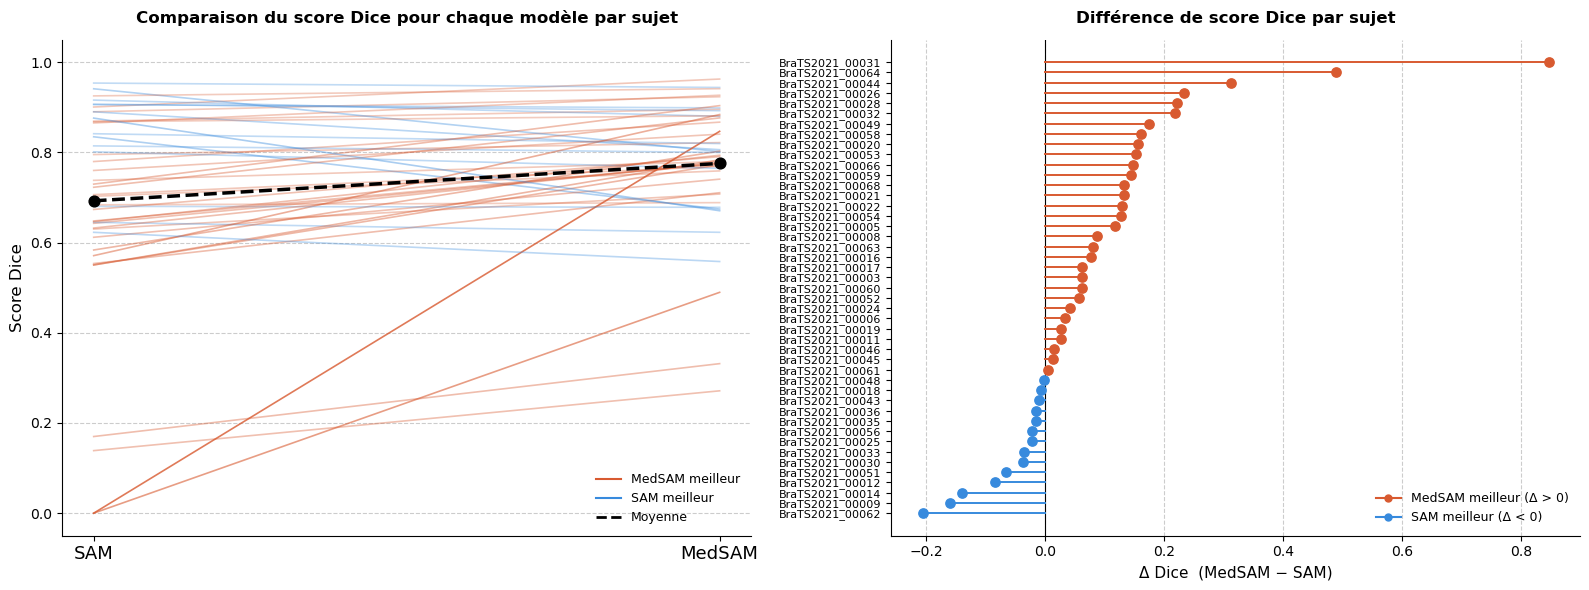

Figure sauvegardée : /home/cassa2/psy3019/projet_repro/output_data/figure_comparaison_dice.png


In [6]:
couleurs = {'SAM': '#378ADD', 'MedSAM': '#D85A30'}

diff = tableau_resultat['medsam_dice'] - tableau_resultat['sam_dice']
subjects = tableau_resultat.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Parallel coordinates ──────────────────────────────────────────────────
for subj in subjects:
    sam_val    = tableau_resultat.loc[subj, 'sam_dice']
    medsam_val = tableau_resultat.loc[subj, 'medsam_dice']
    d = medsam_val - sam_val
    color  = '#D85A30' if d > 0 else '#378ADD'   # MedSAM better → coral, SAM better → blue
    alpha  = 0.3 + 0.6 * abs(d)                  # bigger difference = more opaque
    ax1.plot([0, 1], [sam_val, medsam_val],
                color=color, alpha=alpha, linewidth=1.2, zorder=2)

# Means
mu_sam    = tableau_resultat['sam_dice'].mean()
mu_medsam = tableau_resultat['medsam_dice'].mean()
ax1.plot([0, 1], [mu_sam, mu_medsam],
            color='black', linewidth=2.5, linestyle='--', zorder=5, label='Moyenne')
ax1.scatter([0, 1], [mu_sam, mu_medsam],
            color='black', s=60, zorder=6)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['SAM', 'MedSAM'], fontsize=13)
ax1.set_ylabel('Score Dice', fontsize=12)
ax1.set_ylim(-0.05, 1.05)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title('Comparaison du score Dice pour chaque modèle par sujet', fontsize=12,
                fontweight='bold', pad=12)

legend_elems = [
    mlines.Line2D([], [], color='#D85A30', linewidth=1.5, label='MedSAM meilleur'),
    mlines.Line2D([], [], color='#378ADD', linewidth=1.5, label='SAM meilleur'),
    mlines.Line2D([], [], color='black',   linewidth=2,   linestyle='--', label='Moyenne'),
]
ax1.legend(handles=legend_elems, fontsize=9, frameon=False, loc='lower right')

# ── Lollipop — MedSAM − SAM ───────────────────────────────────────────────
order   = diff.sort_values().index          # sort by difference
y_pos   = np.arange(len(order))
diff_sorted = diff[order]

for i, (subj, val) in enumerate(diff_sorted.items()):
    color = '#D85A30' if val > 0 else '#378ADD'
    ax2.plot([0, val], [i, i], color=color, linewidth=1.4, zorder=2)
    ax2.scatter(val, i, color=color, s=45, zorder=3)

ax2.axvline(0, color='black', linewidth=0.8, linestyle='-', zorder=1)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(order, fontsize=8)
ax2.set_xlabel('Δ Dice  (MedSAM − SAM)', fontsize=11)
ax2.xaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Différence de score Dice par sujet', fontsize=12,
                fontweight='bold', pad=12)

legend_elems2 = [
    mlines.Line2D([], [], color='#D85A30', linewidth=1.5,
                    marker='o', markersize=5, label='MedSAM meilleur (Δ > 0)'),
    mlines.Line2D([], [], color='#378ADD', linewidth=1.5,
                    marker='o', markersize=5, label='SAM meilleur (Δ < 0)'),
]
ax2.legend(handles=legend_elems2, fontsize=9, frameon=False, loc='lower right')

fig.tight_layout()

plt.show()

filepath = os.path.join(output_dir, "figure_comparaison_dice.png")
fig.savefig(filepath, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Figure sauvegardée : {filepath}")


In [7]:
def figure_2_variables(df_long, variable1, variable2, ymin=0, ymax=1, save_dir = './figures') :
    fig, ax = plt.subplots(figsize=(6, 5))

    df_pr = df_long.melt(id_vars='modele', value_vars=[variable1, variable2],
                        var_name='metrique', value_name='valeur')

    sns.boxplot(data=df_pr, x='metrique', y='valeur', hue='modele',
                palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
                fill=False, linewidth=1.5, fliersize=0, ax=ax)

    sns.stripplot(data=df_pr, x='metrique', y='valeur', hue='modele',
                palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
                alpha=0.7, jitter=True, dodge=True, legend=False,
                size=5, ax=ax)

    ax.set_xlabel('')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xticklabels([variable1, variable2], fontsize=12)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f'Mesure de {variable1} et {variable2} pour Med-sam et sam', fontsize=12, loc='center', pad=20, fontweight='bold')
    ax.yaxis.set_tick_params(labelsize=8)

    # Grille discrète
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.set_axisbelow(True)

    # Bordures
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Légende
    ax.legend(title='Modèles :', fontsize=11, frameon=False)
    legend = ax.legend(title='Modèles :', fontsize=11, frameon=False)
    legend.get_title().set_horizontalalignment('left')

    plt.savefig(f'./figures/boxplot_{variable1}_{variable2}.png', dpi=300, bbox_inches='tight')
    print(f'{variable1, variable2} sauvegardé')
    #plt.show()
    #plt.close()

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import fonctions as fc

tableau_resultat = pd.read_csv('./resultats/resultats_tableau.csv', index_col=0)
print(tableau_resultat.columns)

# Mettre dans le bon format
df_sam = tableau_resultat[['sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100', 'sam_AVG_seg2gt', 'sam_AVG_gt2seg']].copy()
df_sam.columns = ['dice', 'precision', 'recall', 'HD100', 'AVG_seg2gt', 'AVG_gt2seg']
df_sam['modele'] = 'SAM'

df_medsam = tableau_resultat[['medsam_dice', 'medsam_precision', 'medsam_recall', 'medsam_HD100', 'medsam_AVG_seg2gt', 'medsam_AVG_gt2seg']].copy()
df_medsam.columns = ['dice', 'precision', 'recall', 'HD100', 'AVG_seg2gt', 'AVG_gt2seg']
df_medsam['modele'] = 'MedSAM'

df_long = pd.concat([df_sam, df_medsam])

print(df_long.columns)

# Figure 1 : Dice 
fc.figure_dice(df_long)

# Figure 2 : Precision, recall 
fc.figure_2_variables(df_long, 'precision', 'recall')

# Figure 4 : comparaison entre modèles 
fc.figure_comparaison_dice(tableau_resultat, save_dir='./figures')

# Figure 4 : AVG surface dist 
fc.figure_2_variables(df_long, 'AVG_seg2gt', 'AVG_gt2seg', 0, 20)


'''
# Figure 2 : 

fig, ax = plt.subplots(figsize=(6, 5))

df_pr = df_long.melt(id_vars='modele', value_vars=['precision', 'recall'],
                     var_name='metrique', value_name='valeur')

sns.boxplot(data=df_pr, x='metrique', y='valeur', hue='modele',
            palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
            fill=False, linewidth=1.5, fliersize=0, ax=ax)

sns.stripplot(data=df_pr, x='metrique', y='valeur', hue='modele',
              palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
              alpha=0.7, jitter=True, dodge=True, legend=False,
              size=5, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(['Precision', 'Recall'], fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Mesure de Précision et Recall pour Med-sam et sam', fontsize=12, loc='center', pad=20, fontweight='bold')
ax.yaxis.set_tick_params(labelsize=8)

# Grille discrète
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)

# Bordures
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Légende
ax.legend(title='Modèles :', fontsize=11, frameon=False)
legend = ax.legend(title='Modèles :', fontsize=11, frameon=False)
legend.get_title().set_horizontalalignment('left')

plt.savefig('./figures/boxplot_precision_recall.png', dpi=300, bbox_inches='tight')
print('precision_recall sauvegardé')
#plt.show()
plt.close()

# Figure 3 : HD100 

fig, ax = plt.subplots(figsize=(5, 5))

modeles = ['SAM', 'MedSAM']
couleurs = {'SAM': '#378ADD', 'MedSAM': '#D85A30'}

# --- Boxplot avec transparence via boxprops ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele][['modele', 'HD100']]
    bp = ax.boxplot(
        vals['HD100'],
        positions=[i],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color=couleurs[modele], linewidth=1.5),
        capprops=dict(color=couleurs[modele], linewidth=1.5),
        boxprops=dict(facecolor=couleurs[modele] + '40',   # '40' ≈ 25% opacité
                      edgecolor=couleurs[modele], linewidth=1.5),
        flierprops=dict(marker=''),
        showfliers=False
    )

    # Ligne de moyenne tiretée
    mu = vals['HD100'].mean()
    ax.hlines(mu, i - 0.25, i + 0.25,
              colors=couleurs[modele], linewidths=1.5,
              linestyles='--', zorder=5)

# --- Points décalés à droite ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['HD100']
    x = np.random.normal(i, 0.04, size=len(vals)) # i + 0,32 pour tasser à droite 
    ax.scatter(x, vals, color=couleurs[modele], alpha=0.6, s=18, zorder=3)

# --- Annotations μ ± σ ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['HD100']
    mu, sigma = vals.mean(), vals.std()
    ax.annotate(
        f'M={mu:.2f} ± {sigma:.2f}',
        xy=(i, 0.02), ha='center', va='bottom',
        fontsize=9, color=couleurs[modele], fontstyle='italic'
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['SAM', 'MedSAM'], fontsize=12)
ax.set_ylabel('HD100', fontsize=12)
ax.set_xlabel('')
#ax.set_ylim(-0.07, 1)
ax.yaxis.set_tick_params(labelsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('HD100 score — SAM vs MedSAM', fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./figures/HD100.png', dpi=300, bbox_inches='tight')
print('HD100 sauvegardé')
#plt.show()
plt.close()

# Figure 4 : comparaison entre modèles 

fc.figure_comparaison_dice(tableau_resultat, save_dir='./figures')

# Figure 5 : AVSD 

'''